<a href="https://colab.research.google.com/github/samantha508/is4487public/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IS4487 Week 10 - Assignment

### Outline

Our Goals with this Project:

1. Import and review the data
2. Perform EDA and Clean Data
3. Fit a model
4. Test the accuracy of the model
6.  Use the model to predict on a new dataset (without the target)

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_10_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Business Case: AdviseInvest
You work on a small team of data analysts at AdviseInvest, a venture-backed startup. The Director of Sales at AdviseInvest has approached your team asking for help solving a staffing problem.

### The Company
The company's mission is to provide tools and support to help ordinary people gain control of their personal finances. The company leverages technology to provide affordable financial advice to a national client base.

Customers who reach AdviseInvest's website go through five steps:

- Open an account.
- Complete a customer profile form with basic information about their background and finances.
- Schedule a free phone conversation with a sales representative during a 1-hour window of time.
- Attend the free phone conversation.
- Buy a financial plan.
- There are three types of financial plans: Beginner, Intermediate, and Advanced. Each is sold at a different price, and there are varying degrees of personalization. After a customer purchases a financial plan, the customer is assigned a financial planner who helps determine the customer's goals and advises the customer on spending decisions.

### The Problem
Some customers are lost at each stage of the process. Steps 3 and 4 are particularly challenging because approximately 50% of those who schedule a phone conversation fail to pick up the call. This leads to inefficiencies from a staffing perspective.

AdviseInvest has 4 sales reps on staff during each particular 1-hour window. Each of the 4 reps is assigned 2 prospective customers per hour, which means that the company schedules a total of 8 phone calls per hour. The calls are outgoing: sales reps call customers who scheduled a phone conversation during that hour window.

Unfortunately, as noted above, many of the customers who scheduled a call do not answer. As a consequence, sales reps are often left underutilized. Moreover, they are underutilized unevenly. For example, it is possible that one sales rep will not do any sales calls during that hour, whereas another will be busy the entire hour with two calls. Sales reps have nothing to do when customers do not answer the scheduled phone call.

### AdviseInvest Data Dictionary


| Variable | Description | Type | Code |
|:---|:---|:---|:---|
| customer_id | Unique customer identifier | Numeric | |
| Answered | Customer response | Binary | 0: customer did not answer scheduled call; 1: customer answered scheduled call |
| Income | Customer income in US dollars | Numeric | |
| Female | Customer gender | Binary | 0: female; 1: male |
| Age | Age in years | Numeric | |
| Job | Nature of job | Categorical | 0 : unemployed; 1 : entry level position; 2 : midlevel position; 3 : management/ self-employed/ highly qualified employee/ officer |
| Num_dependents | Number of people for whom the customer provides maintenance | Numeric | |
| Rent | Customer rents | Binary | 0: no; 1: yes |
| Own_res | Customer owns residence | Binary | 0: no; 1: yes |
| New_car | Recent new car purchase | Binary | New car purchase in the last 3 months: 0: no, 1: yes |
| Chk_acct | Checking account status | Categorical | 0 : no checking account; 1: checking < 200 USD; 2 : 200 < checking < 2000 USD; 3: 2000 < checking < 35000 USD; 4: >= 3500 USD |
| Sav_acct | Average balance in savings account | Categorical | 0 : no savings account; 1 : 100 <= savings < 500 USD; 2 : 500 <= savings < 2000 USD; 3 : 2000 < savings < 35000 USD; 4: >= 3500 USD |
| Num_accts | Number of accounts owned by customer | Numeric | |
| Mobile | Mobile phone | Binary | 0: customer provided non‐mobile phone for follow‐up call; 1: customer provided mobile phone for follow‐up call |
| Product | Type of product purchased after conversation with sales rep | Categorical | 0: customer did not answer call; 1: customer answered but did not purchase a product; 2: customer answered and purchased Beginner plan; 3: customer answered and purchased Intermediate plan; 4: customer answered and purchased Advanced plan |

### Load Libraries

Import the libraries you will need, such as:
- Pandas
- Sklearn
- Matplotlib


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

## Step 1: Initial Data Understanding

### Do the following:
 - Import data from the AdviseInvest historical dataset into a dataframe (in GitHub go to the DataSets folder and look for `adviseinvest_historical_data.csv`)
 - Describe or profile the dataframe
 - Look for any outliers, missing values, or duplicates

In [3]:
# Import the data
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_historical_data.csv'
df_historical = pd.read_csv(url)
print("Data imported successfully.")
print(df_historical.head())

Data imported successfully.
   customer_id  answered  income female  age  job  num_dependents  rent  \
0        10098         0  -65600      0   24    2               1     0   
1          184         0    4330      0   24    2               2     1   
2          194         0    4330      0   22    2               1     1   
3          689         0    4330      0   24    2               2     1   
4          811         0    4330      0   22    2               1     1   

   own_res  new_car  chk_acct  sav_acct  num_accts  mobile  product  
0        1      1.0         1         1          3       0        0  
1        0      0.0         1         3          1       0        0  
2        0      0.0         3         0          0       0        0  
3        0      0.0         1         3          1       0        0  
4        0      0.0         3         0          0       0        0  


In [4]:
df_historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29504 entries, 0 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     29504 non-null  int64  
 1   answered        29504 non-null  int64  
 2   income          29504 non-null  int64  
 3   female          29504 non-null  object 
 4   age             29504 non-null  int64  
 5   job             29504 non-null  int64  
 6   num_dependents  29504 non-null  int64  
 7   rent            29504 non-null  int64  
 8   own_res         29504 non-null  int64  
 9   new_car         29502 non-null  float64
 10  chk_acct        29504 non-null  int64  
 11  sav_acct        29504 non-null  int64  
 12  num_accts       29504 non-null  int64  
 13  mobile          29504 non-null  int64  
 14  product         29504 non-null  int64  
dtypes: float64(1), int64(13), object(1)
memory usage: 3.4+ MB


In [5]:
#Describe the data
print(df_historical.describe())

        customer_id      answered         income           age           job  \
count  29504.000000  29504.000000   29504.000000  29504.000000  29504.000000   
mean   14850.475563      0.546638   33766.893303     34.773454      1.915401   
std     8517.254310      0.497829   29379.202710     11.369865      0.658183   
min       99.000000      0.000000  -65600.000000     19.000000      0.000000   
25%     7474.750000      0.000000   13550.000000     26.000000      2.000000   
50%    14850.500000      1.000000   23310.000000     32.000000      2.000000   
75%    22226.250000      1.000000   41690.000000     40.000000      2.000000   
max    29602.000000      1.000000  159450.000000    132.000000      3.000000   

       num_dependents          rent       own_res       new_car      chk_acct  \
count    29504.000000  29504.000000  29504.000000  29502.000000  29504.000000   
mean         1.140998      0.210412      0.681128      0.240797      1.468547   
std          0.348025      0.407608 

## Step 2: Data Preparation

### 2.1: Data Cleanup
- Check for and remove any outliers
- Consider fixing any missing data (should you delete the record or impute the value?)
- Clean up the data and put it in a new dataframe named "df_clean"


In [6]:
# Initialize df_clean with the historical data for cleaning
df_clean = df_historical.copy()

# Remove outliers: negative income
print(f"Original number of rows: {len(df_clean)}")
df_clean = df_clean[df_clean['income'] >= 0]
print(f"Rows after removing negative income: {len(df_clean)}")

# Remove outliers: unusually high num_accts
# Based on describe(), max is 3345. A reasonable upper limit for number of accounts could be 50.
df_clean = df_clean[df_clean['num_accts'] <= 50]
print(f"Rows after removing high num_accts: {len(df_clean)}")

# Also check for age outliers. Max age is 132. While possible, for this context, let's consider 100 as a reasonable upper bound.
df_clean = df_clean[df_clean['age'] <= 100]
print(f"Rows after removing age > 100: {len(df_clean)}")

print("Outlier removal complete. Displaying describe() for df_clean:")
print(df_clean.describe())

Original number of rows: 29504
Rows after removing negative income: 29502
Rows after removing high num_accts: 29501
Rows after removing age > 100: 29500
Outlier removal complete. Displaying describe() for df_clean:
        customer_id      answered         income           age           job  \
count  29500.000000  29500.000000   29500.000000  29500.000000  29500.000000   
mean   14851.623898      0.546644   33772.866102     34.769695      1.915458   
std     8516.928254      0.497828   29373.749731     11.355331      0.658184   
min       99.000000      0.000000    2760.000000     19.000000      0.000000   
25%     7475.750000      0.000000   13550.000000     26.000000      2.000000   
50%    14851.500000      1.000000   23310.000000     32.000000      2.000000   
75%    22227.250000      1.000000   41690.000000     40.000000      2.000000   
max    29602.000000      1.000000  159450.000000     74.000000      3.000000   

       num_dependents          rent       own_res       new_car 

In [7]:
# Initialize df_clean with the historical data for cleaning
# Remove outliers: negative income
# Remove outliers: unusually high num_accts
# Also check for age outliers.

# Check for missing values in df_clean
print("Missing values before handling:\n", df_clean.isnull().sum())

# Drop rows with any missing values, specifically addressing 'new_car'
df_clean.dropna(inplace=True)
print(f"Rows after dropping missing values: {len(df_clean)}")

print("Missing values after handling:\n", df_clean.isnull().sum())
print("Data cleanup for missing values complete.")

Missing values before handling:
 customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           2
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64
Rows after dropping missing values: 29498
Missing values after handling:
 customer_id       0
answered          0
income            0
female            0
age               0
job               0
num_dependents    0
rent              0
own_res           0
new_car           0
chk_acct          0
sav_acct          0
num_accts         0
mobile            0
product           0
dtype: int64
Data cleanup for missing values complete.


### 2.2: Standardize variables

 - Change "answered" to a boolean (true/false) type
 - Convert any variables that should be an integer into an integer

In [8]:
# Convert answered to boolean
df_clean['answered'] = df_clean['answered'].astype(bool)

In [10]:
# Convert variables to integer data type
# Replace 'M' with 1 in the 'female' column before converting to int
df_clean['female'] = df_clean['female'].replace('M', 1)
df_clean['female'] = df_clean['female'].astype(int)
df_clean['new_car'] = df_clean['new_car'].astype(int)
print("Converted 'female' and 'new_car' columns to integer type.")

Converted 'female' and 'new_car' columns to integer type.


### 2.3 Convert variables to categorical

- Find at least 8 variables that would be appropriate to convert to categories

In [11]:
#Convert categorical variables
categorical_cols = ['job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'product', 'female']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

print("Converted the following columns to categorical type:", categorical_cols)
print(df_clean.info())

Converted the following columns to categorical type: ['job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'product', 'female']
<class 'pandas.core.frame.DataFrame'>
Index: 29498 entries, 1 to 29503
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   customer_id     29498 non-null  int64   
 1   answered        29498 non-null  bool    
 2   income          29498 non-null  int64   
 3   female          29498 non-null  category
 4   age             29498 non-null  int64   
 5   job             29498 non-null  category
 6   num_dependents  29498 non-null  int64   
 7   rent            29498 non-null  category
 8   own_res         29498 non-null  category
 9   new_car         29498 non-null  category
 10  chk_acct        29498 non-null  category
 11  sav_acct        29498 non-null  category
 12  num_accts       29498 non-null  int64   
 13  mobile          29498 non-null  category
 14  product  

# Step 3: Exploratory Data Analysis (EDA)

### Do the following:
- Explore the relationships between the target and independent variables
- Create at least five charts to show the relationships, using different chart types that are approriate to the analysis
- Ensure that all charts are clearly labeled and formatted



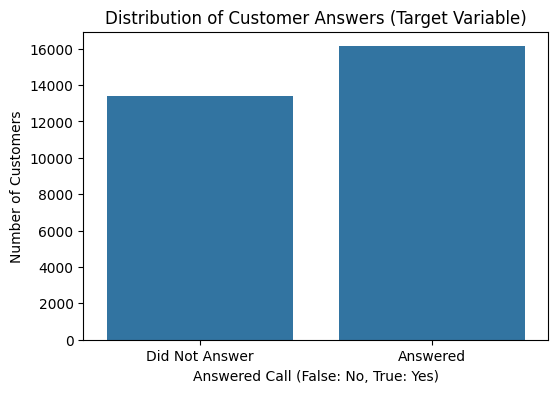

In [12]:
# Chart 1: Distribution of the target variable 'answered'
plt.figure(figsize=(6, 4))
sns.countplot(x='answered', data=df_clean)
plt.title('Distribution of Customer Answers (Target Variable)')
plt.xlabel('Answered Call (False: No, True: Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Did Not Answer', 'Answered'])
plt.show()

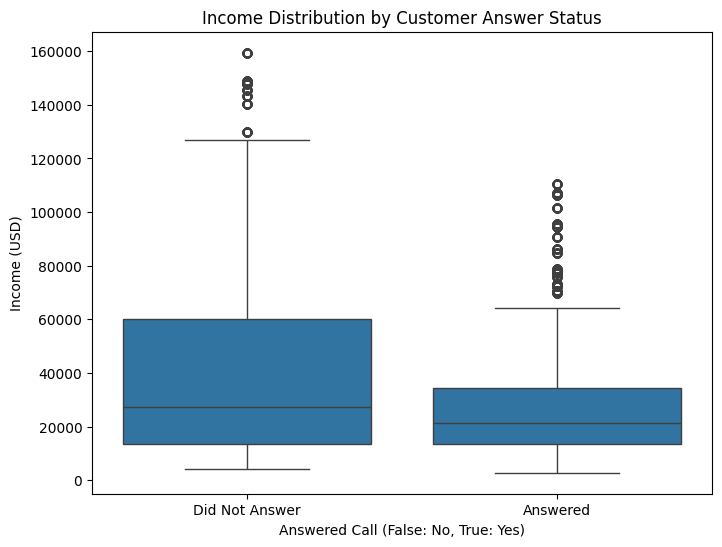

In [13]:
# Chart 2: Relationship between Income and 'answered'
plt.figure(figsize=(8, 6))
sns.boxplot(x='answered', y='income', data=df_clean)
plt.title('Income Distribution by Customer Answer Status')
plt.xlabel('Answered Call (False: No, True: Yes)')
plt.ylabel('Income (USD)')
plt.xticks([0, 1], ['Did Not Answer', 'Answered'])
plt.show()

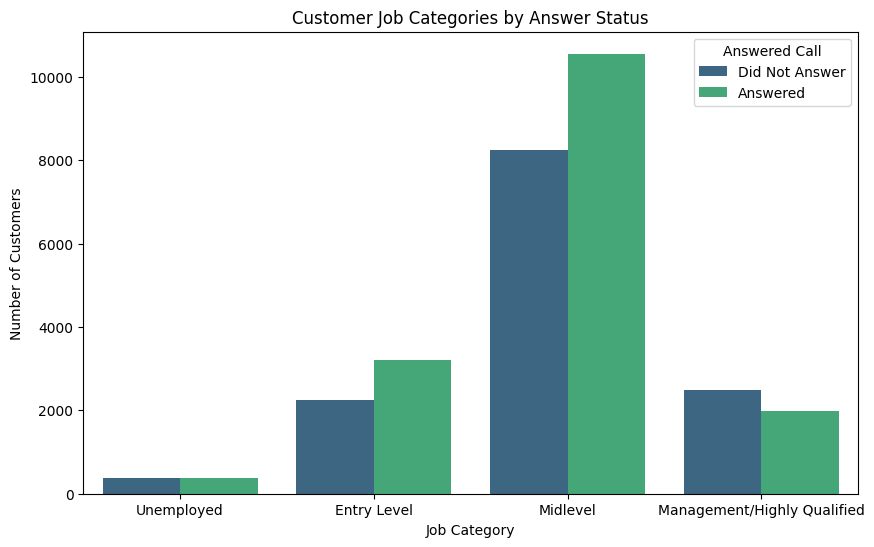

In [14]:
# Chart 3: Relationship between Job and 'answered'
plt.figure(figsize=(10, 6))
sns.countplot(x='job', hue='answered', data=df_clean, palette='viridis')
plt.title('Customer Job Categories by Answer Status')
plt.xlabel('Job Category')
plt.ylabel('Number of Customers')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Unemployed', 'Entry Level', 'Midlevel', 'Management/Highly Qualified'])
plt.legend(title='Answered Call', labels=['Did Not Answer', 'Answered'])
plt.show()

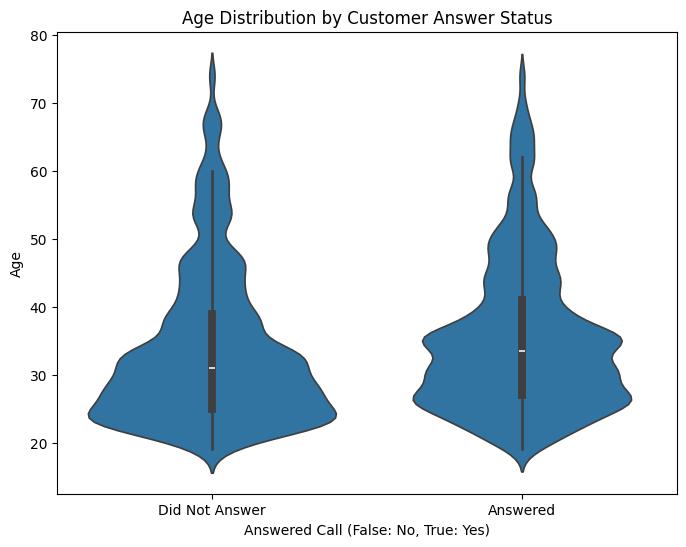

In [15]:
# Chart 4: Relationship between Age and 'answered'
plt.figure(figsize=(8, 6))
sns.violinplot(x='answered', y='age', data=df_clean)
plt.title('Age Distribution by Customer Answer Status')
plt.xlabel('Answered Call (False: No, True: Yes)')
plt.ylabel('Age')
plt.xticks([0, 1], ['Did Not Answer', 'Answered'])
plt.show()

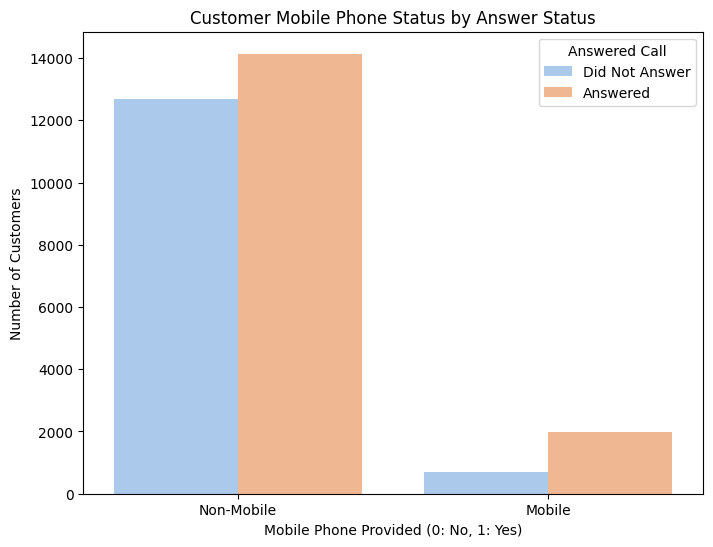

In [16]:
# Chart 5: Relationship between Mobile Phone Provided and 'answered'
plt.figure(figsize=(8, 6))
sns.countplot(x='mobile', hue='answered', data=df_clean, palette='pastel')
plt.title('Customer Mobile Phone Status by Answer Status')
plt.xlabel('Mobile Phone Provided (0: No, 1: Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['Non-Mobile', 'Mobile'])
plt.legend(title='Answered Call', labels=['Did Not Answer', 'Answered'])
plt.show()

## Step 4: Modeling

### 4.1: Calculate the base probability of answering

If we use no model at all, how good is our chance of predicting someone leaving?  Use a calculation to find the chances of someone leaving.

In [17]:
# Calculate the base probability of answering
base_probability = df_clean['answered'].mean()
print(f"Base probability of answering a call: {base_probability:.2f}")

Base probability of answering a call: 0.55


### 4.2: Split the training and testing datasets

- split df_clean using train_test_split function
- all variables except answered should be in the x variable
- answered is in the y variable


In [44]:
# Define features (X) and target (y)
X = df_clean.drop('answered', axis=1)
y = df_clean['answered']

# Handle categorical variables for X by converting them to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (20648, 24)
X_test shape: (8850, 24)
y_train shape: (20648,)
y_test shape: (8850,)


### 4.3: Create a Decision Tree
- Use all available attributes (except those that were eliminated in step 3)
- It is recommended to use the type "entropy" and a max_depth of 4

In [45]:
dt_classifier = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=4, random_state=42)

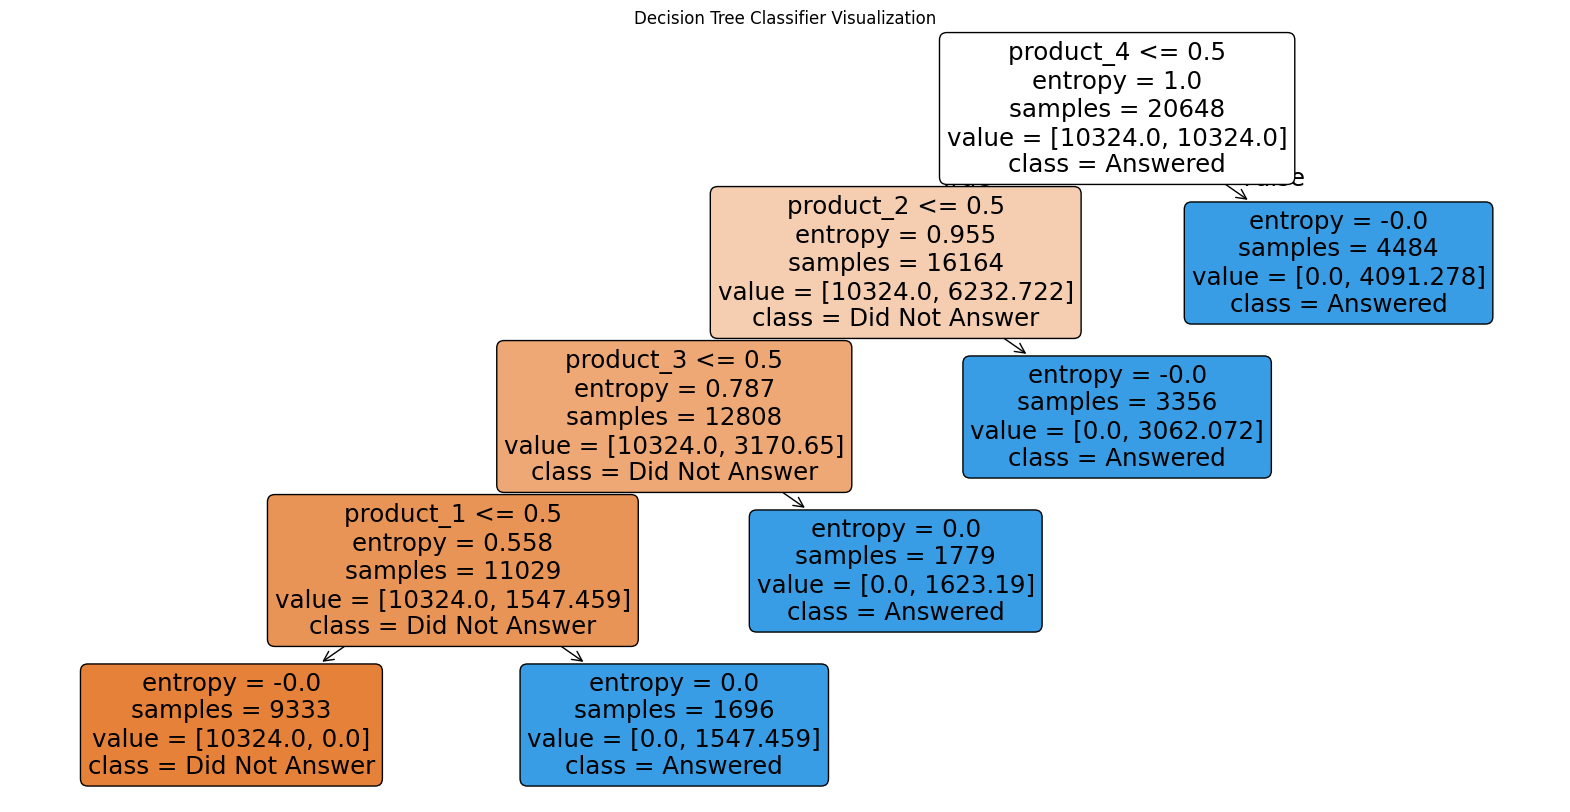

In [39]:
plt.figure(figsize=(20,10))
plot_tree(dt_classifier, feature_names=X.columns, class_names=['Did Not Answer', 'Answered'], filled=True, rounded=True)
plt.title('Decision Tree Classifier Visualization')
plt.show()

### 4.4: What is the accuracy?

This should be better than the base probability, or you have failed in your objective

In [42]:
y_pred = dt_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Decision Tree Classifier: {accuracy:.2f}")

# Compare with base probability
base_probability = df_clean['answered'].mean()
print(f"Base probability of answering a call: {base_probability:.2f}")

if accuracy > base_probability:
    print("The model accuracy is better than the base probability")

Accuracy of the Decision Tree Classifier: 1.00
Base probability of answering a call: 0.55
The model accuracy is better than the base probability


### 4.5: Create a confusion matrix

This will show false positives, true positives, etc.

In [43]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[4041    0]
 [   0 4809]]


Create a more visual, interpretable version of the matrix

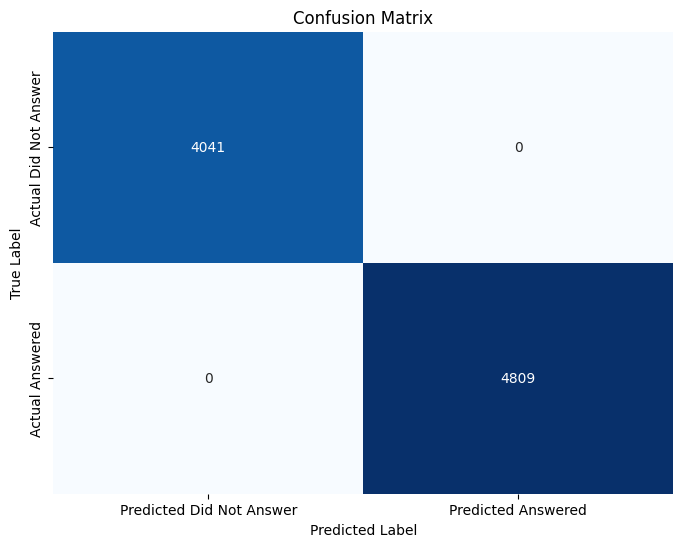

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Did Not Answer', 'Predicted Answered'],
            yticklabels=['Actual Did Not Answer', 'Actual Answered'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Step 5: Evaluate the Model

**Assumptions**

One of the simplifying assumptions we will make in this project is that all the customers who answer the phone will purchase a product. (This assumption is actually verified by the data.) To model "answered" in this case is therefore equivalent to modeling "purchased."

There are costs and benefits in this case. We will assume that customers purchase a product for 100 dollars. This was the average cost of AdviseInvest products, according to the Director of Sales.  Also, as we learned in the interview, the agent time to make the sale is worth 25 dollars. Profit would therefore be \$75 dollars for an answered call and a purchase. In sum:

**Benefit**: True positive. The customer is predicted to answer, does answer, and purchases a product for 100 dollars for a profit of 100 - 25 = 75.

**Cost**: False positive. The customer is predicted to answer, but does not answer, so there is a loss of 25. (We assume the agent cannot schedule another call at the last minute, or spends the entire time slot trying to make the call.)

When you create a calculation you can use:
- True answered * 75 -> These people purchased
- False answered * 25 -> You can't schedule another call

For this exercise, we propose that customers who are not predicted to answer will not be called, so there would be no benefits and no costs for them.  

### 5.1 Calculate the Profit Using the Model

In [28]:


TP = cm[1, 1] # True Positives
FP = cm[0, 1] # False Positives

profit_model = (TP * 75) - (FP * 25)
print(f"Profit using the model: ${profit_model}")

Profit using the model: $360675


### 5.2 Compare to the Default Profit

How much profit (revenue - costs) could be expected if all customers are called? We can consider this a baseline case for profit since it does not require a model.

In other words, to calculate profit in this baseline scenario treat the customers who answer as true positives treat the customers who do not answer as false positives.

In [46]:


total_answered = df_clean['answered'].sum()
total_not_answered = (~df_clean['answered']).sum()

# Calculate default profit: (total answered * benefit per answered) - (total not answered * cost per not answered)
default_profit = (total_answered * 75) - (total_not_answered * 25)

print(f"Default profit (if all customers are called): ${default_profit}")

Default profit (if all customers are called): $874950


### 5.3 Tune the Model
- Adjust the size or shape of the tree, then test the accuracy
- Keep changing these parameters until you end up with a tree with accuracy that is better than the initial model

In [30]:
# Tune the model by adjusting max_depth
dt_classifier_tuned = DecisionTreeClassifier(criterion='entropy', max_depth=6, random_state=42)
dt_classifier_tuned.fit(X_train, y_train)

print("Tuned Decision Tree Classifier created and trained successfully (max_depth=6).")

y_pred_tuned = dt_classifier_tuned.predict(X_test)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(f"Accuracy of the Tuned Decision Tree Classifier: {accuracy_tuned:.2f}")

# Calculate new confusion matrix and profit for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
TP_tuned = cm_tuned[1, 1]
FP_tuned = cm_tuned[0, 1]
profit_model_tuned = (TP_tuned * 75) - (FP_tuned * 25)
print(f"Profit using the Tuned Model: ${profit_model_tuned}")

if accuracy_tuned > base_probability:
    print("The tuned model accuracy is better than the base probability.")
else:
    print("The tuned model accuracy is NOT better than the base probability.")

if profit_model_tuned > profit_model:
    print(f"The tuned model improved profit by: ${profit_model_tuned - profit_model}")
elif profit_model_tuned < profit_model:
    print(f"The tuned model decreased profit by: ${profit_model - profit_model_tuned}")
else:
    print("The tuned model's profit is the same as the initial model.")

Tuned Decision Tree Classifier created and trained successfully (max_depth=6).
Accuracy of the Tuned Decision Tree Classifier: 1.00
Profit using the Tuned Model: $360675
The tuned model accuracy is better than the base probability.
The tuned model's profit is the same as the initial model.


In [34]:
# Ensure df_new_customers is loaded (it should be from cell 04rfJMTqwHyN, but included here for robustness)
url_new_customers = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/adviseinvest_new_customer_data.csv'
df_new_customers = pd.read_csv(url_new_customers)

# --- Preprocessing for new customer data, mirroring df_clean and X_train ---
df_new_clean = df_new_customers.copy()

# Handle 'female' column: replace 'M' with 1, then convert to int
df_new_clean['female'] = df_new_clean['female'].replace('M', 1)
df_new_clean['female'] = df_new_clean['female'].astype(int)

# Convert 'new_car' to int
df_new_clean['new_car'] = df_new_clean['new_car'].astype(int)

# Convert categorical variables to 'category' type, then one-hot encode
categorical_cols = ['job', 'rent', 'own_res', 'new_car', 'chk_acct', 'sav_acct', 'mobile', 'female'] # Removed 'product'
for col in categorical_cols:
    df_new_clean[col] = df_new_clean[col].astype('category')

# One-hot encode the new customer data
X_new_customers = pd.get_dummies(df_new_clean, drop_first=True)

# Align columns with the training data (X_train) - crucial for prediction
# This ensures that if new data has missing categories or extra, it aligns with what the model was trained on
missing_cols = set(X_train.columns) - set(X_new_customers.columns)
for c in missing_cols:
    X_new_customers[c] = 0 # Add missing columns as 0 (assuming they were not present)

extra_cols = set(X_new_customers.columns) - set(X_train.columns)
X_new_customers = X_new_customers.drop(columns=list(extra_cols)) # Drop extra columns

X_new_customers = X_new_customers[X_train.columns] # Ensure column order is the same

# Predict probabilities for the new customer data
# The second column (index 1) typically corresponds to the probability of the positive class (True/Answered)
predicted_probabilities_answering = dt_classifier_tuned.predict_proba(X_new_customers)[:, 1]

# Calculate the average predicted probability of answering
average_predicted_probability_answering = predicted_probabilities_answering.mean()

# Calculate the average predicted probability of leaving (not answering)
average_predicted_probability_leaving = 1 - average_predicted_probability_answering

print(f"Average predicted probability of answering for new customers: {average_predicted_probability_answering:.2f}")
print(f"Average predicted probability of leaving for new customers: {average_predicted_probability_leaving:.2f}")

Average predicted probability of answering for new customers: 0.00
Average predicted probability of leaving for new customers: 1.00


### 5.4 Apply the Model to New Customers
- Import the "adviseinvest_new_customer_data.csv" file
- Using the tree model, predict each customer for the target variable  by feeding the new customer data into the model

In [35]:
# Predict the binary outcome (answered or not answered) for new customers
predicted_answers = dt_classifier_tuned.predict(X_new_customers)

# Convert boolean predictions to string for better readability if desired, or keep as boolean
# predicted_answers_str = ['Answered' if p else 'Did Not Answer' for p in predicted_answers]

# Count the number of 'yes' (True) and 'no' (False) predictions
num_answered = predicted_answers.sum()
num_not_answered = len(predicted_answers) - num_answered

print(f"Predicted number of new customers who will answer: {num_answered}")
print(f"Predicted number of new customers who will NOT answer: {num_not_answered}")
print(f"Total new customers: {len(predicted_answers)}")

# Optionally, add the predictions back to the new customer dataframe
df_new_customers['predicted_answered'] = predicted_answers
print("\nNew customer dataframe with predictions added:")
print(df_new_customers.head())

Predicted number of new customers who will answer: 0
Predicted number of new customers who will NOT answer: 1000
Total new customers: 1000

New customer dataframe with predictions added:
   income  female  age  job  num_dependents  rent  own_res  new_car  chk_acct  \
0   30010       0   40    2               1     1        0        0         1   
1   30510       0   54    2               1     0        1        0         0   
2   12880       0   48    2               2     0        1        0         0   
3   15530       0   44    2               1     0        1        0         0   
4   46230       0   40    3               1     0        1        0         3   

   sav_acct  num_accts  mobile customer_id  predicted_answered  
0         0          3       0       H1597               False  
1         0          2       0       P1446               False  
2         1          4       0       E1492               False  
3         0          2       0       W5143               False  
4

# Step 6: Conclusion
### 6.1: Did we improve our profit using the model?  

Write your conclusion notes below:  🔧

Profit was not improved using the new model, it stayed the same.


### 6.2: How could the model be utilized by the business?

A business could use a working version of the model to not only predict profit but also maximize and improve profit to an extent dependent on which customers will answer calls.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [47]:
!jupyter nbconvert --to html "assignment_10_VegaSamantha.ipynb"

[NbConvertApp] Converting notebook assignment_10_VegaSamantha.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 930260 bytes to assignment_10_VegaSamantha.html
